In [186]:
import os
from typing_extensions import TypedDict
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_core.tools import tool
from langchain_community.tools import DuckDuckGoSearchRun
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.graph import StateGraph, add_messages
from openai import OpenAI
from rich.console import Console
from rich.panel import Panel
from rich.pretty import Pretty
from pydantic import BaseModel, Field
from langchain_tavily import TavilySearch
from rich import print
from langchain.agents import create_agent
from typing import Annotated, Literal, List, TypedDict
from rich.markdown import Markdown
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_core.output_parsers import PydanticOutputParser
import asyncio
from langchain_experimental.utilities import PythonREPL

console = Console()

repl = PythonREPL()

def show(response):
    console.print(
        Panel(
            # Pretty(response.model_dump()),
            Pretty(response),
            title="🤖 LLM Response",
            border_style="green",
            expand=False
        )
    )

def show_markdown(response):
    Console().print(Markdown(response))

load_dotenv()

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

# llm = ChatOpenAI(
#     model="stepfun/step-3.5-flash:free",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="deepseek/deepseek-v3.2",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="x-ai/grok-4.1-fast",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="openai/gpt-4o-mini",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="openai/gpt-oss-120b",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="openai/gpt-5-nano",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="anthropic/claude-haiku-4.5",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="gemini-2.5-flash-lite",
#     api_key=os.getenv("GEMINI_API_KEY"),
#     base_url="https://generativelanguage.googleapis.com/v1beta/openai/"
# )

llm = ChatOpenAI(
    model="gemini-2.5-flash",
    api_key=os.getenv("GEMINI_API_KEY"),
    base_url="https://generativelanguage.googleapis.com/v1beta/openai/"
)

In [187]:
repl.run("print(1+1)")  # → "2"

'2\n'

In [ ]:
class graph_state(BaseModel):
    question: str = Field(..., description = "Question to write code for")
    code: str = Field(..., description = "Code generated for the question")
    is_correct: bool = Field(..., description = "Code generated is correct or not")
    error: str = Field(..., description = "Error description")
    iterations: int = Field(..., description = "No of tries done to execute correct code")
    output: str = Field(..., description = "Output after running code")
    feedback: str = Field(..., description = "Feedback on the code")

In [189]:
class coder_state(BaseModel):
    code: str = Field(..., description="Generated code")

In [190]:
class evaluator_state(BaseModel):
    feedback: str = Field(..., description = "Feedback on the code")
    is_correct: bool = Field(..., description = "Code generated is correct or not")

In [191]:
def coder(state: graph_state) -> graph_state:
    question = state.question
    parser = PydanticOutputParser(pydantic_object=coder_state)
    response = llm.invoke(f"""You are a helpful code generator. You have to generate code in the provided format for the given question.
    Make sure code prints output using print().
           
    Question:

    {question}

    {parser.get_format_instructions()}

    """)
    parsed = parser.parse(response.content)
    return {
        'code': parsed.code,
    }

In [192]:
def executor(state: graph_state) -> graph_state:
    code = state.code
    try:
        result = repl.run(code)
        return{
            'is_correct': True,
            'error': '',
            'output': result
        }
    except Exception as e:
        return{
            'is_correct': False,
            'error': str(e),
            'output': ''
        }

In [193]:
def evaluator(state: graph_state) -> graph_state:
    if state.error:
        return {
            'feedback': f"Code failed with error {state.error}",
            'is_correct': False
        }
    else:
        question = state.question
        code = state.code
        output = state.output
        parser = PydanticOutputParser(pydantic_object=evaluator_state)
        response = llm.invoke(f"""You are a helpful code evaluator. You have been given a question, a code
        provided as answer and output coming after executing that code. You have to analyze everything and then 
        tell if the code is correct and giving required output or not based on the code and output provided.
        Please respond in provided format only. If you think the code is not aligned with the requirement,
        please tell that code is not correct strictly. Also please give proper feedback on how the code can be
        improved.            

        Question:

        {question}

        Code:

        {code}

        Output:

        {output}

        {parser.get_format_instructions()}

        """)
        parsed = parser.parse(response.content)
        return {
            'feedback': parsed.feedback,
            'is_correct': parsed.is_correct
        }

In [194]:
def fixer(state: graph_state) -> graph_state:
    question = state.question
    code = state.code
    error = state.error
    feedback = state.feedback
    parser = PydanticOutputParser(pydantic_object=coder_state)
    prompt = f"""
        You are a helpful assistant. You have been provided with a question and the code provided as a result
        to that question. Also, you have been provided errors coming after executing that code or if
        no errors there, some feedback has been provided. You have to fix the code after analyzing the error
        and the feedback. Make sure code prints output using print()

        Question:

        {question}

        Code:

        {code}

        Error:

        {error}

        Feedback:

        {feedback}

        {parser.get_format_instructions()}

    """
    response = llm.invoke(prompt)
    parsed = parser.parse(response.content)
    return {
        'code': parsed.code,
        'iterations': state.iterations + 1
    }

In [195]:
def router(state: graph_state) -> graph_state:
    is_correct = state.is_correct
    iterations = state.iterations
    if iterations == 2:
        return 'end'
    elif not is_correct:
        return 'fixer'
    else:
        return 'end'

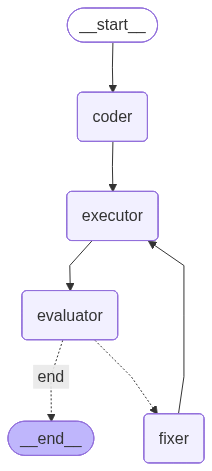

In [196]:
graph = StateGraph(graph_state)

graph.add_node('coder', coder)
graph.add_node('executor', executor)
graph.add_node('evaluator', evaluator)
graph.add_node('fixer', fixer)

graph.add_edge(START, 'coder')
graph.add_edge('coder', 'executor')
graph.add_edge('executor', 'evaluator')
graph.add_edge('fixer', 'executor')
graph.add_conditional_edges('evaluator', router, {
    'fixer': 'fixer', 'end': END
})

coder_graph = graph.compile()

from IPython.display import Image, display
Image(coder_graph.get_graph().draw_mermaid_png())

In [197]:
graph_obj = graph_state(
    question = 'Write code to return a list of prime numbers till 100',
    code = '',
    is_correct = False,
    error = '',
    iterations = 0,
    output = '',
    feedback = ''
)

In [198]:
for chunk in coder_graph.stream(
    graph_obj,
    stream_mode="updates"
):
    print(chunk)

{
    'coder': {
        'code': 'def is_prime(num):\n    if num < 2:\n        return False\n    for i in range(2, int(num**0.5) + 
1):\n        if num % i == 0:\n            return False\n    return True\n\nprime_numbers = []\nfor number in 
range(2, 101):\n    if is_prime(number):\n        prime_numbers.append(number)\n\nprint(prime_numbers)'
    }
}

{
    'executor': {
        'is_correct': True,
        'error': '',
        'output': '[2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59, 61, 67, 71, 73, 79, 83, 89, 
97]\n'
    }
}

{
    'evaluator': {
        'feedback': 'The code is correct, well-structured, and efficiently finds prime numbers up to 100. The 
`is_prime` function is implemented correctly by checking divisibility only up to the square root of the number. The
main loop iterates through the specified range and correctly uses the `is_prime` function. The output matches the 
expected list of prime numbers. \n\nFor minor improvements, you could add a docstring to the `is_prime` function to
explain its purpose, parameters, and return value, which enhances code readability and 
maintainability.\n\n```python\ndef is_prime(num):\n    """\n    Checks if a given number is prime.\n    A prime 
number is a natural number greater than 1 that has no positive divisors other than 1 and itself.\n    """\n    if 
num < 2:\n        return False\n    for i in range(2, int(num**0.5) + 1):\n        if num % i == 0:\n            
return False\n    return True\n\nprime_numbers = []\nfor number in range(2, 101):\n    if is_prime(number):\n      
prime_numbers.append(number)\n\nprint(prime_numbers)\n```',
        'is_correct': True
    }
}

In [199]:
resp = coder_graph.invoke(graph_obj)

In [200]:
show(resp)

╭──────────────────────────────────────────────── 🤖 LLM Response ────────────────────────────────────────────────╮
│ {                                                                                                               │
│     'question': 'Write code to return a list of prime numbers till 100',                                        │
│     'code': 'def find_primes_up_to_n(n):\n    primes = []\n    for num in range(2, n + 1):\n        is_prime =  │
│ True\n        # Check for factors from 2 up to the square root of num\n        for i in range(2, int(num**0.5)  │
│ + 1):\n            if num % i == 0:\n                is_prime = False\n                break\n        if        │
│ is_prime:\n            primes.append(num)\n    return primes\n\n# Find prime numbers till 100\nprime_numbers =  │
│ find_primes_up_to_n(100)\nprint(prime_numbers)',                                                                │
│     'is_correct': True,                                                                                         │
│     'error': '',                                                                                                │
│     'iterations': 0,                                                                                            │
│     'output': '[2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59, 61, 67, 71, 73, 79, 83, 89,     │
│ 97]\n',                                                                                                         │
│     'feedback': "The code is correct and effectively finds all prime numbers up to 100 using an efficient trial │
│ division method. The logic is clear, and the output matches the expected list of primes. The use of `num**0.5`  │
│ for checking divisibility up to the square root of the number is an efficient optimization. For finding primes  │
│ up to a much larger 'n' (e.g., millions), a Sieve of Eratosthenes algorithm would be significantly more         │
│ efficient, but for `n=100`, the current approach is perfectly acceptable and easy to understand. Adding a       │
│ docstring to the function would improve code documentation."                                                    │
│ }                                                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯